In [2]:
import torch
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

## Validation of QPINN Implementation for a Simple ODE

We consider the following $\textbf{ordinary differential equation (ODE)}$:

$$
\frac{du}{dt} + \lambda \, u(t) \, \big(\kappa + \tan(\lambda t)\big) = 0, 
\quad u(t=0) = u_0,
$$

where:

* $\lambda$ and $\kappa$ are problem parameters
* $u_0$ is the initial condition
* $c$ is a constant determined by $u_0$

The $\textbf{analytical solution}$ of this ODE is:

$$
u(t) = e^{-\kappa \lambda t} \cos(\lambda t) + c
$$



In [3]:
# Problem parameters
lam = 2.0     # λ
kappa = 0.1   # κ
u0 = 1.0      # initial condition u(0)

This sections implements the quantum circuit.

In [4]:
#Quantum Device
n_qubits = 4
n_layers = 2
dev = qml.device("default.qubit", wires=n_qubits)


# U_sigma(x) = tensor_j=1^N exp(-i arcsin(x)/2 * sigma_y^j)
def feature_map(t, t_max=0.9):
    # normalize t once
    t_scaled = 2 * t / t_max - 1
    t_scaled = torch.clamp(t_scaled, -0.999, 0.999)  # safe for arcsin

    for j in range(n_qubits):
        qml.RY(torch.arcsin(t_scaled), wires=j)



# Hardware efficient ansatz
def variational_block(theta):
    for i in range(n_layers):
        for j in range(n_qubits):
            qml.RZ(theta[i, j, 0], wires = j)
            qml.RX(theta[i, j, 1], wires = j)
            qml.RZ(theta[i, j, 2], wires = j)

        for j in range(0, n_qubits - 1, 2):
            qml.CNOT(wires = [j, j+1])
        for j in range(1, n_qubits - 1, 2):
            qml.CNOT(wires = [j, j+1])

@qml.qnode(dev, interface="torch", diff_method="parameter-shift")
def quantum_circuit(x, theta):
    feature_map(x)
    variational_block(theta)
    return qml.expval(qml.sum(*[qml.PauliZ(i) for i in range(n_qubits)]))





In [5]:
#Automatic Differentiation
def f(t, theta):
    return quantum_circuit(t, theta)

def df_dt(t, theta):
    f_val = f(t, theta)
    return torch.autograd.grad(f_val, t, create_graph=True)[0]


## Loss function

In [6]:
def ode_residual(t, theta):
    safe_t = torch.clamp(lam * t, -1.4, 1.4)
    res = df_dt(t, theta) + lam * f(t, theta) * (kappa + torch.tan(safe_t))
    res = torch.nan_to_num(res, nan=0.0, posinf=10.0, neginf=-10.0)
    return res

def loss_function(theta, t_collocation):
    # ODE loss
    eta = 1.1
    
    ode_loss = 0.0
    for t in t_collocation:
        t = t.clone().detach().requires_grad_(True)
        ode_loss += ode_residual(t, theta)**2

    ode_loss /= len(t_collocation)

    # Initial condition loss
    t0 = torch.tensor(0.0, requires_grad=True)
    ic_loss = (f(t0, theta) - u0)**2

    return ode_loss + eta * ic_loss


C:\Users\tiago\AppData\Local\Temp\ipykernel_2076\2988253946.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


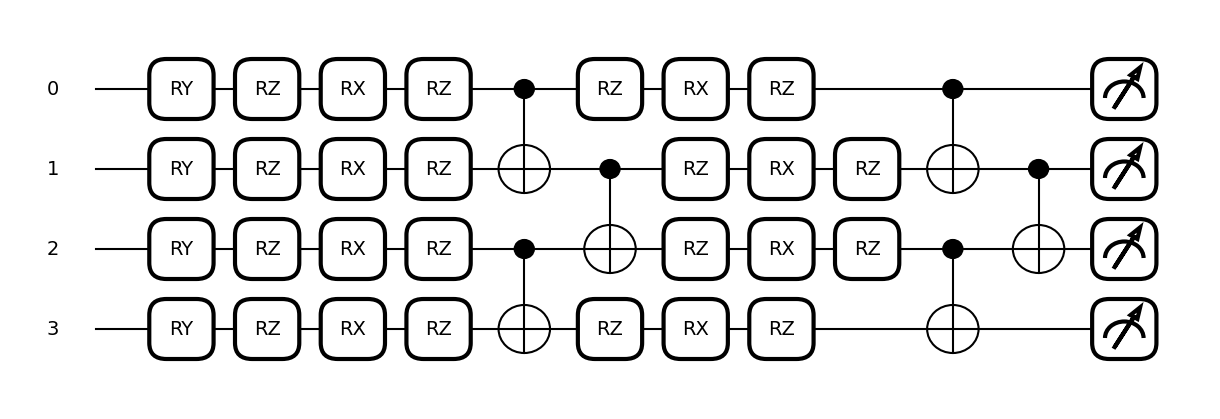

In [7]:

x_val = torch.tensor(0.3)
theta_val = torch.zeros((n_layers, n_qubits, 3), requires_grad=True)

drawer = qml.draw_mpl(quantum_circuit)

fig, ax = drawer(
    x_val,
    theta_val
)

fig.set_size_inches(12, 4)
fig.tight_layout()



We have all functions defined. Now, we procede with the computation.

In [8]:

optimizer = torch.optim.Adam([theta_val], lr=0.001) # set learning rate
# Collocation points
t_max = 1
t_collocation = torch.linspace(0, 0.9, 25)
#t_scaled = 2 * t_collocation / t_max - 1  # maps [0,T] → [-1,1], for the arcsin is only defined for this interval


def ode_residual_debug(t, theta):
    t = t.clone().detach().requires_grad_(True)

    f_val = quantum_circuit(t, theta)
    print("f:", f_val.item())

    df_dt = torch.autograd.grad(
        f_val, t,
        grad_outputs=torch.ones_like(f_val),
        create_graph=True
    )[0]
    print("df/dt:", df_dt.item())

    tan_term = torch.tan(lam * t)
    print("tan(lam t):", tan_term.item())

    return df_dt + lam * f_val * (kappa + tan_term)

print(ode_residual_debug(torch.tensor(0.2), theta_val))


epochs = 10


for epoch in range(epochs):
    optimizer.zero_grad()
    loss = loss_function(theta_val, t_collocation)
    if torch.isnan(loss):
        print("LOSS IS NaN")
        break
    loss.backward()
    optimizer.step()

    if epoch % 1 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")


f: 2.929166987545158
df/dt: 8.518258094787598
tan(lam t): 0.4227932393550873
tensor(11.5810, dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch    0 | Loss = 171.521616
Epoch    1 | Loss = 171.521616
Epoch    2 | Loss = 171.521616
Epoch    3 | Loss = 171.521616
Epoch    4 | Loss = 171.521616
Epoch    5 | Loss = 171.521616
Epoch    6 | Loss = 171.521616
Epoch    7 | Loss = 171.521616
Epoch    8 | Loss = 171.521616
Epoch    9 | Loss = 171.521616


C:\Users\tiago\AppData\Local\Temp\ipykernel_2076\378251815.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_solution = [f(torch.tensor(t), theta_val).item() for t in t_collocation]
C:\Users\tiago\AppData\Local\Temp\ipykernel_2076\378251815.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.exp(-kappa * lam * t) * np.cos(lam * t) + c


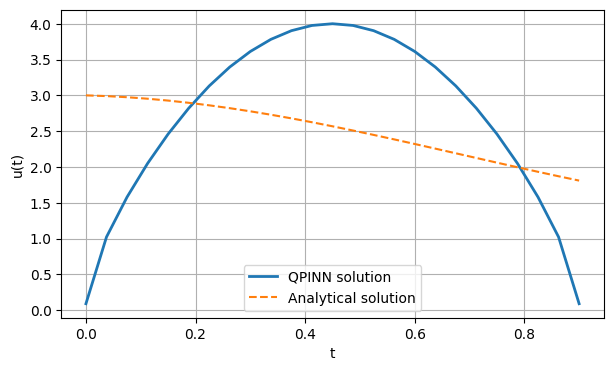

In [9]:
def analytical_solution(t):
    c = u0 + 1
    return np.exp(-kappa * lam * t) * np.cos(lam * t) + c

q_solution = [f(torch.tensor(t), theta_val).item() for t in t_collocation]
exact = analytical_solution(t_collocation)

plt.figure(figsize=(7,4))
plt.plot(t_collocation, q_solution, label="QPINN solution", linewidth=2)
plt.plot(t_collocation, exact, "--", label="Analytical solution")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.grid()
plt.show()
